# Tappy sequence deep learning: GRU et Transformer compact

Ce notebook teste une approche inspiree de TypeFormer, mais adaptee a la detection Parkinson.

TypeFormer original apprend des embeddings pour l'authentification utilisateur avec triplet loss. Ici, on ne reprend pas l'objectif biometrie, car il risquerait d'apprendre l'identite des utilisateurs. On reprend plutot l'idee centrale: traiter des **sequences de frappes** au lieu de simples moyennes journalieres.

Objectif de ce test:
- decouper Tappy en fenetres de 50 frappes;
- entrainer un GRU et un Transformer Encoder compact;
- valider sur des utilisateurs jamais vus;
- comparer a la baseline RF/PSO du notebook Tappy agrege.

## 1. Configuration

Chaque frappe est representee par des timings et des categories simples:

- `hold_time_ms`;
- `latency_time_ms`;
- `flight_time_ms`;
- one-hot `hand` (`L`, `R`, `S`);
- one-hot `direction` (`LL`, `LR`, `RL`, `RR`, `LS`, `SL`, `RS`, `SR`, `SS`).

Les fenetres font `50` frappes, comme dans les experiences TypeFormer ou la longueur `L=50` etait souvent optimale.

In [1]:
from pathlib import Path
import json
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data" / "tappy-keystroke-data-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent

TAPPY_ROOT = ROOT / "data" / "tappy-keystroke-data-1.0.0"
USER_DIR = TAPPY_ROOT / "Archived-users" / "Archived users"
DATA_DIR = TAPPY_ROOT / "Archived-Data" / "Tappy Data"
PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
PROCESSED_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

WINDOW_CACHE = PROCESSED_DIR / "tappy_sequence_windows_len50.npz"
FORCE_REBUILD = False

SEQ_LEN = 50
STRIDE = 50
MIN_WINDOWS_PER_USER = 5
MAX_WINDOWS_PER_USER = 120
BATCH_SIZE = 256
EPOCHS = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"torch: {torch.__version__}")
print(f"device: {DEVICE}")
print(f"Tappy root: {TAPPY_ROOT}")

torch: 2.11.0+cu130
device: cuda
Tappy root: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/tappy-keystroke-data-1.0.0


## 2. Construction des fenetres de frappes

On construit les fenetres depuis les fichiers mensuels Tappy. Les fenetres sont creees par utilisateur et par jour pour eviter de traverser de longues pauses ou des changements de contexte trop forts.

On limite aussi le nombre de fenetres par utilisateur (`MAX_WINDOWS_PER_USER = 120`) afin qu'un utilisateur tres actif ne domine pas l'entrainement.

In [2]:
RAW_COLUMNS = [
    "user_key", "date", "timestamp", "hand", "hold_time_ms", "direction", "latency_time_ms", "flight_time_ms"
]
HAND_VALUES = ["L", "R", "S"]
DIRECTION_VALUES = ["LL", "LR", "RL", "RR", "LS", "SL", "RS", "SR", "SS"]
FEATURE_NAMES = ["hold_time_ms", "latency_time_ms", "flight_time_ms"] + [f"hand_{h}" for h in HAND_VALUES] + [f"direction_{d}" for d in DIRECTION_VALUES]


def parse_user_file(path: Path) -> dict:
    row = {"user_key": path.stem.replace("User_", "")}
    for line in path.read_text(errors="ignore").splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            row[key.strip()] = value.strip()
    return row


def load_users() -> pd.DataFrame:
    users = pd.DataFrame(parse_user_file(path) for path in sorted(USER_DIR.glob("User_*.txt")))
    users["label"] = users["Parkinsons"].map({"False": 0, "True": 1})
    return users.dropna(subset=["label"])


def load_tappy_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=RAW_COLUMNS, usecols=range(8), dtype=str, engine="python")
    for col in ["hold_time_ms", "latency_time_ms", "flight_time_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["date"] = pd.to_numeric(df["date"], errors="coerce")
    df = df.dropna(subset=["user_key", "date", "hold_time_ms", "latency_time_ms", "flight_time_ms"])
    df["date"] = df["date"].astype(int).astype(str).str.zfill(6)
    return df


def clean_tappy_keystrokes(df: pd.DataFrame) -> pd.DataFrame:
    clean = df.copy()
    clean = clean[clean["hold_time_ms"].between(20, 1000)]
    clean = clean[clean["latency_time_ms"].between(0, 5000)]
    clean = clean[clean["flight_time_ms"].between(-1000, 5000)]
    clean = clean[clean["hand"].isin(HAND_VALUES)]
    clean = clean[clean["direction"].isin(DIRECTION_VALUES)]
    return clean


def encode_keystrokes(df: pd.DataFrame) -> np.ndarray:
    timing = df[["hold_time_ms", "latency_time_ms", "flight_time_ms"]].to_numpy(dtype=np.float32)
    hand = np.stack([(df["hand"].to_numpy() == value).astype(np.float32) for value in HAND_VALUES], axis=1)
    direction = np.stack([(df["direction"].to_numpy() == value).astype(np.float32) for value in DIRECTION_VALUES], axis=1)
    return np.concatenate([timing, hand, direction], axis=1)


def build_windows() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    users = load_users()
    labels = dict(zip(users["user_key"], users["label"].astype(int)))
    windows_by_user = {}

    for file_idx, path in enumerate(sorted(DATA_DIR.glob("*.txt")), start=1):
        raw = load_tappy_file(path)
        clean = clean_tappy_keystrokes(raw)
        clean = clean[clean["user_key"].isin(labels)]
        if clean.empty:
            continue
        clean = clean.sort_values(["user_key", "date", "timestamp"])

        for (user_key, date), group in clean.groupby(["user_key", "date"], sort=False):
            arr = encode_keystrokes(group)
            if len(arr) < SEQ_LEN:
                continue
            user_windows = windows_by_user.setdefault(user_key, [])
            for start in range(0, len(arr) - SEQ_LEN + 1, STRIDE):
                user_windows.append(arr[start:start + SEQ_LEN])

    X_list, y_list, group_list = [], [], []
    rng = np.random.default_rng(RANDOM_STATE)
    for user_key, user_windows in sorted(windows_by_user.items()):
        if len(user_windows) < MIN_WINDOWS_PER_USER:
            continue
        selected_idx = np.arange(len(user_windows))
        if len(selected_idx) > MAX_WINDOWS_PER_USER:
            selected_idx = rng.choice(selected_idx, size=MAX_WINDOWS_PER_USER, replace=False)
        for idx in selected_idx:
            X_list.append(user_windows[int(idx)])
            y_list.append(labels[user_key])
            group_list.append(user_key)

    X = np.stack(X_list).astype(np.float32)
    y = np.asarray(y_list, dtype=np.int64)
    groups = np.asarray(group_list)
    return X, y, groups

if WINDOW_CACHE.exists() and not FORCE_REBUILD:
    cached = np.load(WINDOW_CACHE, allow_pickle=True)
    X_seq = cached["X"]
    y_seq = cached["y"]
    groups_seq = cached["groups"]
    print(f"Loaded cached windows: {WINDOW_CACHE}")
else:
    X_seq, y_seq, groups_seq = build_windows()
    np.savez_compressed(WINDOW_CACHE, X=X_seq, y=y_seq, groups=groups_seq, feature_names=np.asarray(FEATURE_NAMES))
    print(f"Saved cached windows: {WINDOW_CACHE}")

print("X", X_seq.shape, "y", y_seq.shape, "groups", groups_seq.shape)
print("users", len(np.unique(groups_seq)))
print(pd.Series(y_seq).value_counts().rename(index={0:"Controle", 1:"Parkinson"}))

Saved cached windows: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/processed/tappy_sequence_windows_len50.npz
X (14426, 50, 15) y (14426,) groups (14426,)
users 176
Parkinson    10698
Controle      3728
Name: count, dtype: int64


### Lecture du cache sequence

Le cache contient **14426 fenetres** de forme `(50, 15)`, issues de **176 utilisateurs**. La classe reste desequilibree: **10698 fenetres Parkinson** contre **3728 controles**.

Le plafonnement a 120 fenetres par utilisateur limite l'effet des gros contributeurs, mais ne change pas le fait que les fenetres d'un meme utilisateur restent tres correlees. La validation groupee par `user_key` est donc indispensable.

## 3. Split groupe et normalisation

On utilise le premier fold d'un `StratifiedGroupKFold`: les utilisateurs du test ne sont jamais vus pendant l'entrainement. Dans l'execution actuelle, le train contient **9615 fenetres / 117 utilisateurs** et la validation **4811 fenetres / 59 utilisateurs**, avec **0 utilisateur en commun**.

Les trois features de timing sont standardisees a partir du train uniquement. Les one-hot restent inchangees.

In [3]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
train_idx, valid_idx = next(cv.split(X_seq, y_seq, groups_seq))

train_users = set(groups_seq[train_idx])
valid_users = set(groups_seq[valid_idx])
print(f"train windows: {len(train_idx)}, valid windows: {len(valid_idx)}")
print(f"train users: {len(train_users)}, valid users: {len(valid_users)}, overlap: {len(train_users & valid_users)}")
print("valid class distribution")
print(pd.Series(y_seq[valid_idx]).value_counts().rename(index={0:"Controle", 1:"Parkinson"}))
assert not (train_users & valid_users)

X_train = X_seq[train_idx].copy()
X_valid = X_seq[valid_idx].copy()
y_train = y_seq[train_idx].copy()
y_valid = y_seq[valid_idx].copy()

# Standardise timing channels only, using train statistics.
timing_mean = X_train[:, :, :3].reshape(-1, 3).mean(axis=0)
timing_std = X_train[:, :, :3].reshape(-1, 3).std(axis=0) + 1e-6
X_train[:, :, :3] = (X_train[:, :, :3] - timing_mean) / timing_std
X_valid[:, :, :3] = (X_valid[:, :, :3] - timing_mean) / timing_std

print("timing_mean", timing_mean)
print("timing_std", timing_std)

train windows: 9615, valid windows: 4811
train users: 117, valid users: 59, overlap: 0
valid class distribution
Parkinson    3566
Controle     1245
Name: count, dtype: int64
timing_mean [119.9201  307.25842 220.02367]
timing_std [ 56.652775 166.08154  151.01135 ]


## 4. Dataset PyTorch et metriques

Le train loader utilise un `WeightedRandomSampler` pour reduire l'effet du desequilibre de classes pendant l'entrainement. Les metriques principales restent `f1_macro` et `balanced_accuracy`.

In [4]:
class KeystrokeSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = KeystrokeSequenceDataset(X_train, y_train)
valid_ds = KeystrokeSequenceDataset(X_valid, y_valid)

class_counts = np.bincount(y_train, minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

loss_weights = torch.tensor((len(y_train) / (2 * np.maximum(class_counts, 1))).astype(np.float32), device=DEVICE)
print("class_counts", class_counts)
print("loss_weights", loss_weights.cpu().numpy())

class_counts [2483 7132]
loss_weights [1.9361659 0.6740746]


In [5]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_binary": f1_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": np.asarray(y_prob),
    }


def train_model(model, train_loader, valid_loader, epochs=EPOCHS, lr=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    history = []
    best_state = None
    best_score = -np.inf

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * len(yb)

        metrics = evaluate_model(model, valid_loader)
        row = {
            "epoch": epoch,
            "train_loss": total_loss / len(train_loader.dataset),
            "valid_balanced_accuracy": metrics["balanced_accuracy"],
            "valid_f1_macro": metrics["f1_macro"],
            "valid_f1_binary": metrics["f1_binary"],
        }
        history.append(row)
        if metrics["f1_macro"] > best_score:
            best_score = metrics["f1_macro"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(row)

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

## 5. Modele 1: GRU baseline

Le GRU est volontairement simple. Il sert de baseline deep learning sequence avant de tester un Transformer.

In [6]:
class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        output, _ = self.gru(x)
        pooled = output.mean(dim=1)
        return self.classifier(self.dropout(pooled))

gru_model = GRUClassifier(input_dim=X_train.shape[-1])
gru_model, gru_history = train_model(gru_model, train_loader, valid_loader)
gru_metrics = evaluate_model(gru_model, valid_loader)
display(gru_history)
print(classification_report(gru_metrics["y_true"], gru_metrics["y_pred"], target_names=["Controle", "Parkinson"]))

{'epoch': 1, 'train_loss': 0.5719423125389028, 'valid_balanced_accuracy': 0.5225368101683233, 'valid_f1_macro': 0.33696924803827316, 'valid_f1_binary': 0.26103286384976526}
{'epoch': 2, 'train_loss': 0.5224663599914892, 'valid_balanced_accuracy': 0.5160919617899529, 'valid_f1_macro': 0.42509724688733597, 'valid_f1_binary': 0.462738977760437}
{'epoch': 3, 'train_loss': 0.49806267529555553, 'valid_balanced_accuracy': 0.5098693146112211, 'valid_f1_macro': 0.3999193527474522, 'valid_f1_binary': 0.4110204081632653}


{'epoch': 4, 'train_loss': 0.4921592741786225, 'valid_balanced_accuracy': 0.5017184835809869, 'valid_f1_macro': 0.4340148052650348, 'valid_f1_binary': 0.5008365867261573}
{'epoch': 5, 'train_loss': 0.48345590676730704, 'valid_balanced_accuracy': 0.4914137762491356, 'valid_f1_macro': 0.41722130764634113, 'valid_f1_binary': 0.47197415922477676}


{'epoch': 6, 'train_loss': 0.46985154094574544, 'valid_balanced_accuracy': 0.4965064971045145, 'valid_f1_macro': 0.4224892871599458, 'valid_f1_binary': 0.47878787878787876}


,epoch,train_loss,valid_balanced_accuracy,valid_f1_macro,valid_f1_binary
0,1,0.571942,0.522537,0.336969,0.261033
1,2,0.522466,0.516092,0.425097,0.462739
2,3,0.498063,0.509869,0.399919,0.411020
3,4,0.492159,0.501718,0.434015,0.500837
4,5,0.483456,0.491414,0.417221,0.471974
5,6,0.469852,0.496506,0.422489,0.478788


              precision    recall  f1-score   support

    Controle       0.26      0.63      0.37      1245
   Parkinson       0.74      0.38      0.50      3566

    accuracy                           0.44      4811
   macro avg       0.50      0.50      0.43      4811
weighted avg       0.62      0.44      0.47      4811



### Lecture GRU

Le GRU n'apporte pas de gain clair. Son meilleur score observe est autour de **0.43 de F1 macro** et **0.50 de balanced accuracy**, donc proche du hasard equilibre.

La matrice de classification montre un compromis instable: le modele recupere une partie des controles, mais au prix d'un recall Parkinson faible dans le meilleur checkpoint retenu. Cela suggere que la sequence brute de 50 frappes n'est pas suffisante telle quelle pour generaliser a de nouveaux utilisateurs Tappy.

## 6. Modele 2: Transformer Encoder compact

Ce modele reprend l'idee TypeFormer au niveau conceptuel: sequence de frappes, projection dense, encodage positionnel, self-attention, pooling puis classification. Il est beaucoup plus petit que TypeFormer pour rester entrainable rapidement sur CPU.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=SEQ_LEN):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        z = self.proj(x)
        z = self.pos(z)
        z = self.encoder(z)
        pooled = z.mean(dim=1)
        return self.classifier(pooled)

transformer_model = TransformerClassifier(input_dim=X_train.shape[-1])
transformer_model, transformer_history = train_model(transformer_model, train_loader, valid_loader)
transformer_metrics = evaluate_model(transformer_model, valid_loader)
display(transformer_history)
print(classification_report(transformer_metrics["y_true"], transformer_metrics["y_pred"], target_names=["Controle", "Parkinson"]))

{'epoch': 1, 'train_loss': 0.5475711995403529, 'valid_balanced_accuracy': 0.5233666015717384, 'valid_f1_macro': 0.3980142838279995, 'valid_f1_binary': 0.3936348408710218}


{'epoch': 2, 'train_loss': 0.5011049695363344, 'valid_balanced_accuracy': 0.494523804697196, 'valid_f1_macro': 0.4419655593857378, 'valid_f1_binary': 0.5305829596412556}


{'epoch': 3, 'train_loss': 0.4872460259538235, 'valid_balanced_accuracy': 0.49578639853863016, 'valid_f1_macro': 0.42123140450859226, 'valid_f1_binary': 0.47656991083285904}


{'epoch': 4, 'train_loss': 0.4657279458662153, 'valid_balanced_accuracy': 0.4967932301274644, 'valid_f1_macro': 0.4432944402860237, 'valid_f1_binary': 0.5308908045977011}


{'epoch': 5, 'train_loss': 0.4579046898562649, 'valid_balanced_accuracy': 0.5179527982935669, 'valid_f1_macro': 0.4283069054707792, 'valid_f1_binary': 0.46823392267340197}


{'epoch': 6, 'train_loss': 0.45267109047046133, 'valid_balanced_accuracy': 0.5000327727060795, 'valid_f1_macro': 0.4207992182162712, 'valid_f1_binary': 0.47052067381317}


,epoch,train_loss,valid_balanced_accuracy,valid_f1_macro,valid_f1_binary
0,1,0.547571,0.523367,0.398014,0.393635
1,2,0.501105,0.494524,0.441966,0.530583
2,3,0.487246,0.495786,0.421231,0.476570
3,4,0.465728,0.496793,0.443294,0.530891
4,5,0.457905,0.517953,0.428307,0.468234
5,6,0.452671,0.500033,0.420799,0.470521


              precision    recall  f1-score   support

    Controle       0.26      0.58      0.36      1245
   Parkinson       0.74      0.41      0.53      3566

    accuracy                           0.46      4811
   macro avg       0.50      0.50      0.44      4811
weighted avg       0.61      0.46      0.49      4811



### Lecture Transformer

Le Transformer Encoder compact obtient le meilleur score des deux modeles sequence, mais reste faible: environ **0.44 de F1 macro** et **0.50 de balanced accuracy**. Il ne bat donc pas l'approche Tappy journaliere avec Voting + PSO, qui atteignait environ **0.58 de F1 macro**.

C'est un resultat important: ajouter de l'attention sur les sequences ne suffit pas. Le modele semble apprendre des patterns qui ne generalisent pas bien entre utilisateurs, probablement a cause du bruit Tappy, des labels auto-declares et de la forte variabilite de contexte.

## 7. Comparaison finale et export

On compare GRU et Transformer sur le meme split groupe. Le meilleur modele est choisi sur `f1_macro`, pas sur accuracy.

,model,balanced_accuracy,f1_macro,f1_binary
1,TransformerEncoder,0.496793,0.443294,0.530891
0,GRU,0.501718,0.434015,0.500837


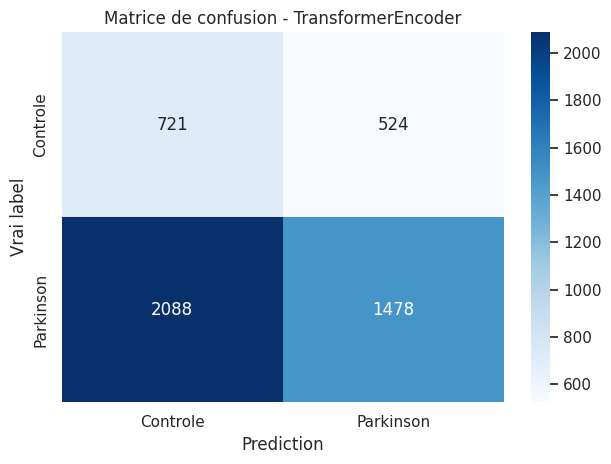

Saved: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/models/keyboard_dynamics_tappy_sequence_dl.pt


In [8]:
summary = pd.DataFrame([
    {"model": "GRU", "balanced_accuracy": gru_metrics["balanced_accuracy"], "f1_macro": gru_metrics["f1_macro"], "f1_binary": gru_metrics["f1_binary"]},
    {"model": "TransformerEncoder", "balanced_accuracy": transformer_metrics["balanced_accuracy"], "f1_macro": transformer_metrics["f1_macro"], "f1_binary": transformer_metrics["f1_binary"]},
]).sort_values("f1_macro", ascending=False)
display(summary)

best_name = summary.iloc[0]["model"]
best_model = gru_model if best_name == "GRU" else transformer_model
best_metrics = gru_metrics if best_name == "GRU" else transformer_metrics
cm = confusion_matrix(best_metrics["y_true"], best_metrics["y_pred"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Controle", "Parkinson"], yticklabels=["Controle", "Parkinson"])
plt.title(f"Matrice de confusion - {best_name}")
plt.xlabel("Prediction")
plt.ylabel("Vrai label")
plt.tight_layout()
plt.show()

artifact = {
    "model_name": best_name,
    "state_dict": best_model.cpu().state_dict(),
    "feature_names": FEATURE_NAMES,
    "seq_len": SEQ_LEN,
    "timing_mean": timing_mean.tolist(),
    "timing_std": timing_std.tolist(),
    "label_mapping": {0: "Controle", 1: "Parkinson"},
    "note": "Prototype sequence DL inspired by TypeFormer; validation uses held-out users.",
}
model_path = MODEL_DIR / "keyboard_dynamics_tappy_sequence_dl.pt"
torch.save(artifact, model_path)
print(f"Saved: {model_path}")

### Conclusion provisoire

Ce test ne valide pas, pour l'instant, l'interet d'une approche TypeFormer-like directe sur Tappy pour Parkinson. Le meilleur modele sequence est le `TransformerEncoder`, avec environ **0.44 de F1 macro**, alors que le notebook Tappy agrege atteignait environ **0.58** avec `VotingClassifier + PSO`.

Interpretation: TypeFormer est puissant pour l'authentification parce qu'il apprend des signatures individuelles. Pour Parkinson, c'est justement ce qu'il faut eviter. Avec une validation par utilisateurs jamais vus, le signal sequence brut semble beaucoup moins robuste que les agregats journaliers.

Prochaines pistes si on veut continuer le deep learning:

- pretraining auto-supervise sur les sequences, puis fine-tuning Parkinson;
- aggregation de plusieurs fenetres par utilisateur avant classification;
- modele MIL (multiple instance learning): plusieurs fenetres -> prediction utilisateur;
- sequence model sur features journalieres longitudinales plutot que sur frappes individuelles;
- comparaison sur NeuroQWERTY, meme si le dataset est petit.

Pour le hackathon, la conclusion pratique est claire: garder RF/PSO ou Voting/PSO comme baseline principale, et presenter le test sequence DL comme une exploration negative mais methodologiquement utile.